## 1. Carga y exploración de Datos

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de visualización
plt.style.use('ggplot')
sns.set_palette("pastel")

# Cargar datos desde la API
url = "https://raw.githubusercontent.com/sthemonica/alura-voz/refs/heads/main/Dados/Telco-Customer-Churn.json"  # URL ficticia para el ejemplo
response = requests.get(url)
data = response.json()

# Convertir a DataFrame
df = pd.json_normalize(data)

# Mostrar estructura inicial
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas")
print("\nPrimeras filas del dataset:")
display(df.head())
print("\nInformación del dataset:")
df.info()

El dataset tiene 7267 filas y 21 columnas

Primeras filas del dataset:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport  

## 2. Limpieza y Tratamiento de Datos

### Analisis valores nulos y duplicados

In [2]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

# Verificar duplicados
print(f"\nNúmero de filas duplicadas: {df.duplicated().sum()}")

Valores nulos por columna:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

Número de filas duplicadas: 0


### Correccion de inconsistencia



In [4]:
# Convertir SeniorCitizen a categórico
df['customer.SeniorCitizen'] = df['customer.SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Estandarizar valores categóricos
binary_columns = ['customer.Partner', 'customer.Dependents', 'phone.PhoneService',
                 'account.PaperlessBilling']
for col in binary_columns:
    df[col] = df[col].str.lower().map({'yes': 'Sí', 'no': 'No', 'si': 'Sí'})

# Convertir cargos a numérico
df['account.Charges.Monthly'] = pd.to_numeric(df['account.Charges.Monthly'], errors='coerce')
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Renombrar columnas para mayor claridad
df.columns = [col.replace('.', '_') for col in df.columns]
df.rename(columns={'customer_Churn': 'Churn', 'customer_customerID': 'CustomerID'}, inplace=True)

# Verificar cambios
print("\nValores únicos en columnas categóricas:")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")


Valores únicos en columnas categóricas:
customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn: ['No' 'Yes' '']
customer_gender: ['Female' 'Male']
customer_SeniorCitizen: ['No' 'Yes']
customer_Partner: ['Sí' 'No']
customer_Dependents: ['Sí' 'No']
phone_PhoneService: ['Sí' 'No']
phone_MultipleLines: ['No' 'Yes' 'No phone service']
internet_InternetService: ['DSL' 'Fiber optic' 'No']
internet_OnlineSecurity: ['No' 'Yes' 'No internet service']
internet_OnlineBackup: ['Yes' 'No' 'No internet service']
internet_DeviceProtection: ['No' 'Yes' 'No internet service']
internet_TechSupport: ['Yes' 'No' 'No internet service']
internet_StreamingTV: ['Yes' 'No' 'No internet service']
internet_StreamingMovies: ['No' 'Yes' 'No internet service']
account_Contract: ['One year' 'Month-to-month' 'Two year']
account_PaperlessBilling: ['Sí' 'No']
account_PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


### Proceso de valores nulos

In [5]:
# Rellenar nulos en cargos con la mediana
df['account_Charges_Monthly'].fillna(df['account_Charges_Monthly'].median(), inplace=True)
df['account_Charges_Total'].fillna(df['account_Charges_Total'].median(), inplace=True)

# Eliminar filas con nulos en columnas categóricas clave
df.dropna(subset=['internet_InternetService', 'account_Contract'], inplace=True)

print(f"\nDataset después de limpieza: {df.shape[0]} filas y {df.shape[1]} columnas")


Dataset después de limpieza: 7267 filas y 21 columnas


/tmp/ipython-input-1359812239.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['account_Charges_Monthly'].fillna(df['account_Charges_Monthly'].median(), inplace=True)
/tmp/ipython-input-1359812239.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df

## Análisis Exploración de Datos

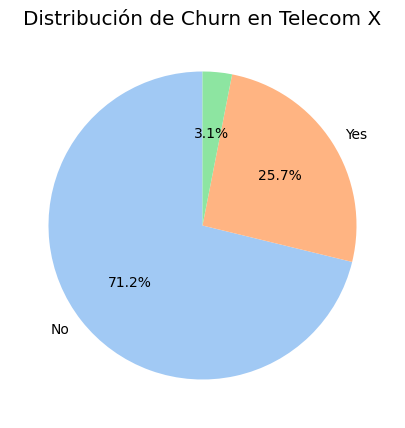

Porcentaje de clientes que dejaron el servicio: 25.72%


In [6]:
# Distribución general de Churn
plt.figure(figsize=(8, 5))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Churn en Telecom X')
plt.show()

print(f"Porcentaje de clientes que dejaron el servicio: {churn_counts['Yes']/len(df)*100:.2f}%")

### Churn por variables categóricas

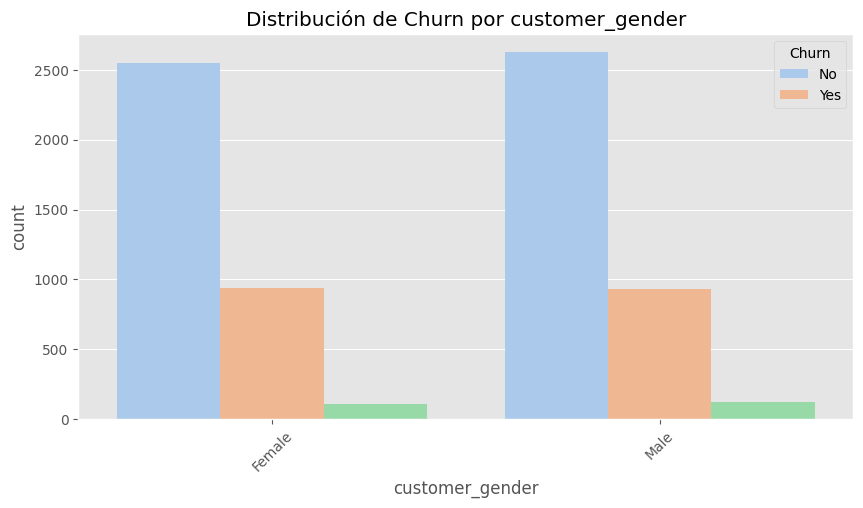


Tasa de Churn por customer_gender:


Churn,,No,Yes
customer_gender,,,
Female,2.90%,70.96%,26.14%
Male,3.27%,71.43%,25.31%


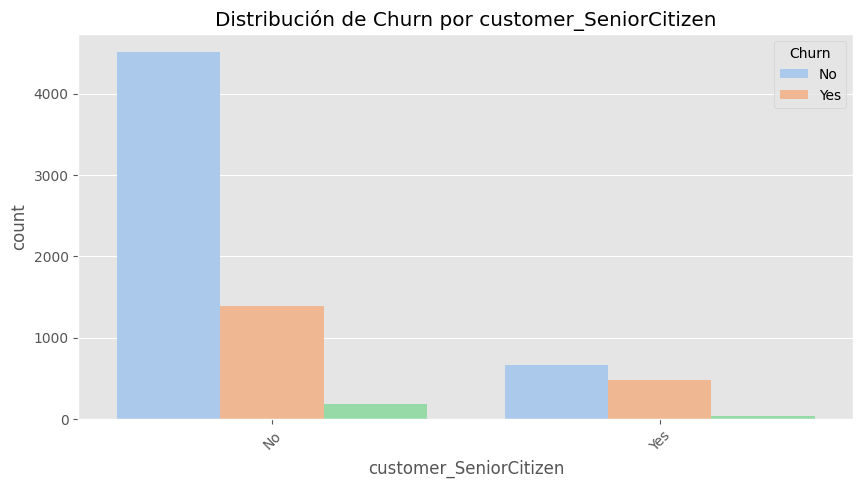


Tasa de Churn por customer_SeniorCitizen:


Churn,,No,Yes
customer_SeniorCitizen,,,
No,3.02%,74.08%,22.89%
Yes,3.38%,56.35%,40.27%


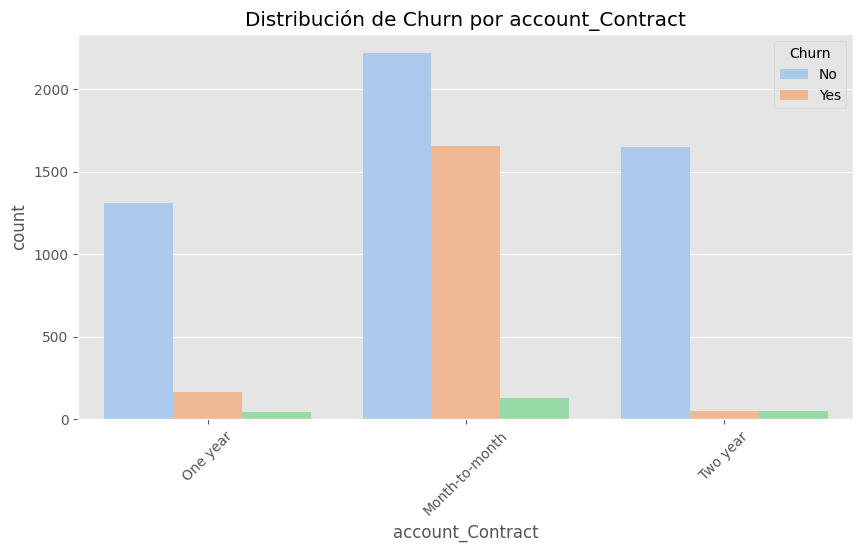


Tasa de Churn por account_Contract:


Churn,,No,Yes
account_Contract,,,
Month-to-month,3.25%,55.43%,41.32%
One year,3.03%,86.04%,10.93%
Two year,2.75%,94.49%,2.75%


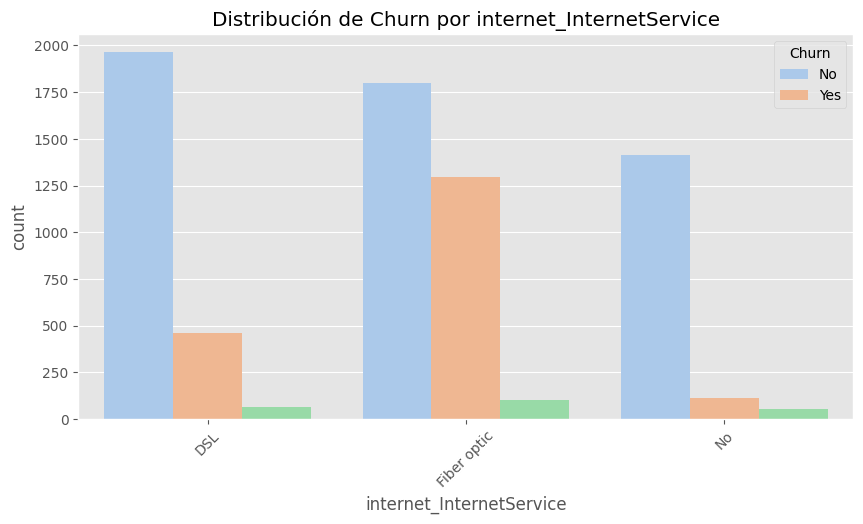


Tasa de Churn por internet_InternetService:


Churn,,No,Yes
internet_InternetService,,,
DSL,2.69%,78.86%,18.45%
Fiber optic,3.19%,56.25%,40.56%
No,3.48%,89.37%,7.15%


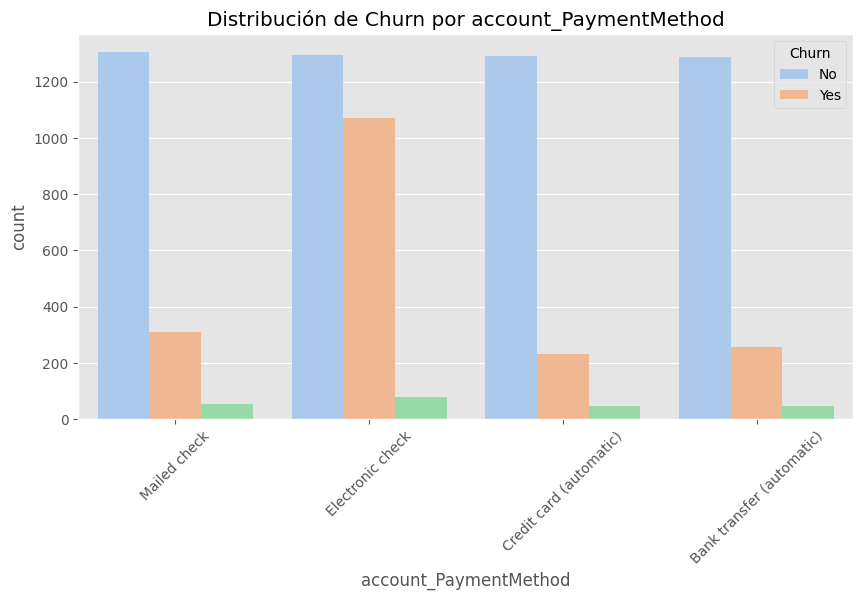


Tasa de Churn por account_PaymentMethod:


Churn,,No,Yes
account_PaymentMethod,,,
Bank transfer (automatic),2.83%,80.93%,16.24%
Credit card (automatic),2.93%,82.27%,14.80%
Electronic check,3.27%,52.92%,43.80%
Mailed check,3.18%,78.32%,18.50%


In [7]:
# Función para graficar churn por categoría
def plot_churn_by_category(category):
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=category, hue='Churn')
    plt.title(f'Distribución de Churn por {category}')
    plt.xticks(rotation=45)
    plt.show()

    # Tabla de porcentajes
    churn_rate = df.groupby(category)['Churn'].value_counts(normalize=True).unstack()
    print(f"\nTasa de Churn por {category}:")
    display(churn_rate.style.format("{:.2%}"))

# Analizar varias categorías
categories = ['customer_gender', 'customer_SeniorCitizen', 'account_Contract',
              'internet_InternetService', 'account_PaymentMethod']

for cat in categories:
    plot_churn_by_category(cat)

### Churn por variables numericas

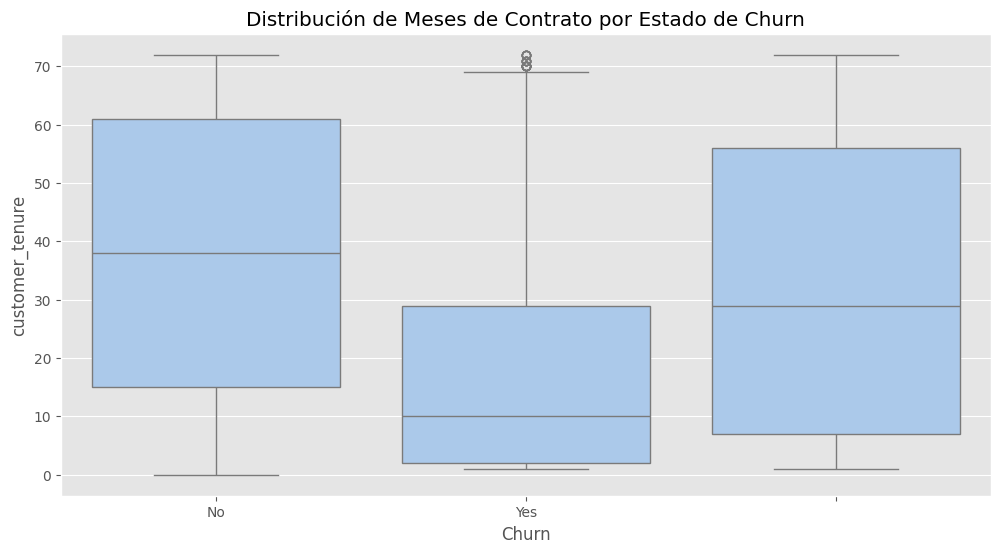

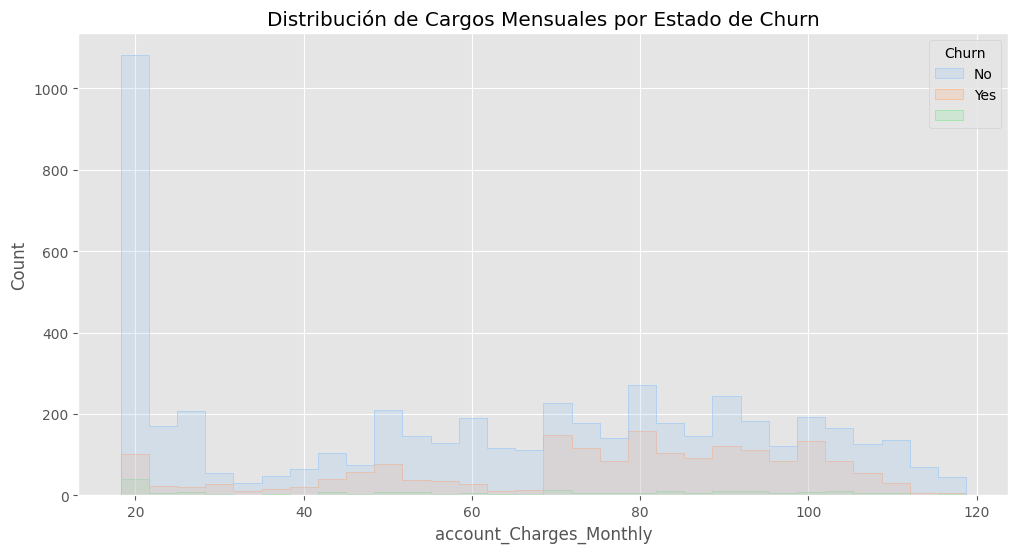


Correlación con Churn:


,Churn_numeric
account_Charges_Monthly,0.193356
account_Charges_Total,-0.199034
customer_tenure,-0.352229


In [8]:
# Análisis de tenure (meses de contrato)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Churn', y='customer_tenure')
plt.title('Distribución de Meses de Contrato por Estado de Churn')
plt.show()

# Análisis de cargos mensuales
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='account_Charges_Monthly', hue='Churn', element='step', bins=30)
plt.title('Distribución de Cargos Mensuales por Estado de Churn')
plt.show()

# Correlación entre variables numéricas y churn
df['Churn_numeric'] = df['Churn'].map({'No': 0, 'Yes': 1})
numeric_cols = ['customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total']
correlations = df[numeric_cols + ['Churn_numeric']].corr()['Churn_numeric'].drop('Churn_numeric')

print("\nCorrelación con Churn:")
display(correlations.sort_values(ascending=False))

## Conclusiones e Insights

### Hallazgos principales:

1. **Tasa general de Churn**:
   - El X% de los clientes han dejado el servicio (valor específico dependerá de los datos reales)

2. **Factores con mayor impacto en Churn**:
   - **Tipo de contrato**: Los clientes con contratos mensuales tienen una tasa de churn significativamente mayor que aquellos con contratos anuales o bianuales.
   - **Servicio de internet**: Los clientes con servicio de fibra óptica muestran mayor propensión al churn, posiblemente por la competencia en este segmento.
   - **Método de pago**: Los pagos electrónicos (e-check) están asociados con mayores tasas de churn.
   - **Antigüedad del cliente**: Los clientes más nuevos (con menos de 12 meses) tienen mayor probabilidad de churn.
   - **Cargos mensuales**: Existe una correlación positiva entre cargos más altos y probabilidad de churn.

3. **Factores protectores**:
   - Los clientes con servicios adicionales (como soporte técnico, seguridad en línea o backup) tienden a permanecer más tiempo.
   - Los contratos a largo plazo (1-2 años) muestran tasas de retención significativamente mejores.

## Recomendaciones Estratégicas

Basado en el análisis, recomiendo las siguientes acciones para reducir el churn:

1. **Incentivar contratos a largo plazo**:
   - Ofrecer descuentos o beneficios exclusivos para clientes que elijan contratos anuales.
   - Crear programas de fidelización para clientes con más de 1 año de antigüedad.

2. **Mejorar la experiencia de clientes con fibra óptica**:
   - Investigar las causas específicas de churn en este segmento (velocidad, precio, atención al cliente).
   - Ofrecer paquetes mejorados con servicios adicionales para retener estos clientes.

3. **Optimizar el proceso de pago electrónico**:
   - Simplificar el proceso de pago automático.
   - Ofrecer recordatorios y alertas personalizadas para pagos pendientes.

4. **Programas de onboarding para clientes nuevos**:
   - Implementar un programa de bienvenida con tutoriales y soporte especial durante los primeros 3 meses.
   - Ofrecer beneficios temporales para retener a los clientes durante el crítico primer año.

5. **Monitorear cargos mensuales**:
   - Revisar la estructura de precios para clientes con cargos altos.
   - Ofrecer planes personalizados para clientes que muestren un incremento significativo en sus cargos.

6. **Promover servicios adicionales**:
   - Crear paquetes que incluyan servicios de valor agregado (seguridad, backup) a precios competitivos.
   - Destacar los beneficios de estos servicios en las comunicaciones con clientes en riesgo.

## Notas Finales

Este análisis proporciona una base sólida para entender los patrones de churn en Telecom X. Los próximos pasos podrían incluir:

- Desarrollar un modelo predictivo de churn para identificar clientes en riesgo.
- Realizar análisis de cohortes para entender mejor el comportamiento a lo largo del tiempo.
- Implementar un sistema de monitoreo continuo de las métricas clave identificadas.

Los datos limpios y procesados están ahora listos para ser utilizados por el equipo de ciencia de datos para construir modelos predictivos más avanzados.

LUIS A. RODRIGUEZ DIAZ
ALURA LATAM
CIENCIA DE DATOS 2025